## Imports & initialisations

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time
import warnings

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import RandomUnderSampler
from sklearn.datasets import make_classification
from sklearn.metrics import (
    confusion_matrix, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_curve,
    roc_auc_score,
    average_precision_score
)
from xgboost import XGBClassifier



In [2]:
# Set the warning filter to "ignore" to suppress all warnings
warnings.filterwarnings("ignore")

## Fonctions

In [3]:
def plot_classes(y): 
    x_,y_ = np.unique_counts(y)
    bars = plt.bar(x_,y_,color=['lightgreen', 'salmon'])
    for bar in bars:
        height = bar.get_height()
        offset = height * 0.001 
        plt.text(bar.get_x() + bar.get_width()/2., height + offset,
             f'{height:,}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.xlabel('isFraud')
    plt.xticks(ticks=x_)
    plt.show()

In [4]:
def plot_confusion_matrix(y_test, y_pred):
    conf_matrix = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False, linewidths=5)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

## Chargement des données

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
data = load_iris()
X, y  = data['data'],  data['target']

for k,v in enumerate(y):
    y[k] = 1 if v>1 else v

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2,random_state=32)

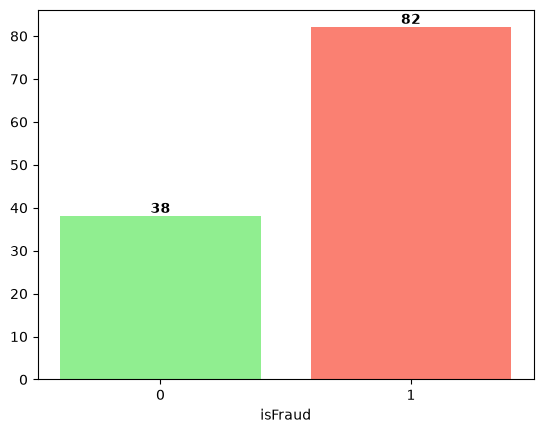

In [6]:
plot_classes(y_train)

## Comparaison des stratégies de resampling

In [14]:
class Resultat:
    def __init__(self, name, y_test, y_pred, start, end):
        self.content = {
            'stratégie': name,
            'auprc': average_precision_score(y_test, y_pred),
            'recall_@_0.5': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'temps (s)': round(end - start, 4),
        }
        
        
class Runner:
    results = []
    models = []

    def _add_results(self, model, resultat):
        self.models.append(model)
        self.results.append(resultat.content)

    def run(self, method_name, *args, **kwargs):
        method =  globals().get(method_name)
        if not method or not callable(method):
            raise AttributeError(f"la méthode '{method_name}' n'existe pas.")
        results = method(*args, **kwargs)
        self._add_results(**results)


In [15]:
runner = Runner()

### Baseline (pas de stratégie de gestion du déséquilibre des classes)

In [16]:
def train():
    bst = XGBClassifier(device="cuda")
    start = time.time()
    bst.fit(X_train, y_train)
    start = time.time()
    bst.set_params(device="cpu")
    end = time.time()
    y_pred = bst.predict(X_test)
    return {"model":bst, "resultat": Resultat("baseline",y_test, y_pred, start,end)}
    
runner.run("train")

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


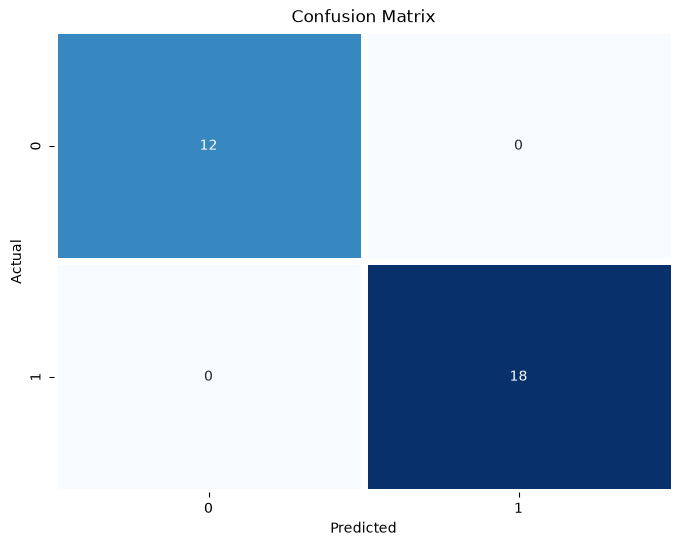

In [21]:
plot_confusion_matrix(y_test,runner.models[0].predict(X_test))

### Pondération des classes par XGBoost

In [22]:
def train():
    ratio = (y_train==0).sum()/(y_train==1).sum()
    print(f"Pondération avec un ratio  de {ratio}")
    bst = XGBClassifier(device="cuda",scale_pos_weight=ratio)
    start = time.time()
    bst.fit(X_train, y_train)
    end = time.time()
    bst.set_params(device="cpu")
    y_pred = bst.predict(X_test)
    return {"model":bst, "resultat": Resultat("xgboost pondéré",y_test, y_pred, start,end)}

runner.run("train")

Pondération avec un ratio  de 0.4634146341463415


Precision: 1.0
Recall: 1.0
F1 Score: 1.0


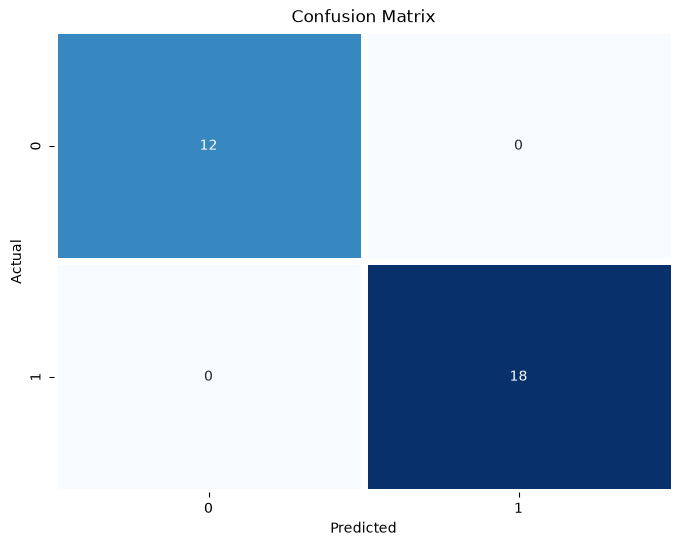

In [23]:
plot_confusion_matrix(y_test,runner.models[1].predict(X_test))

### Random undersampling

In [24]:
rus = RandomUnderSampler(sampling_strategy="majority",random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)

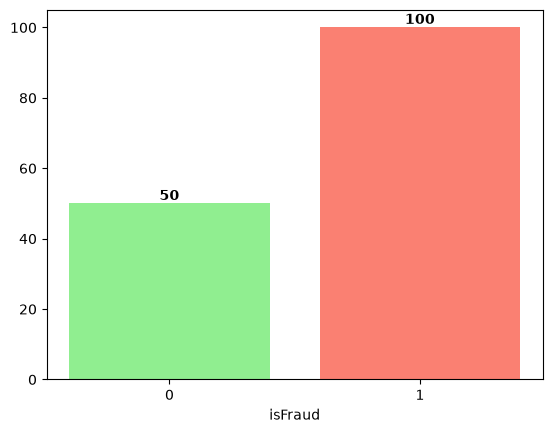

In [25]:
plot_classes(y)

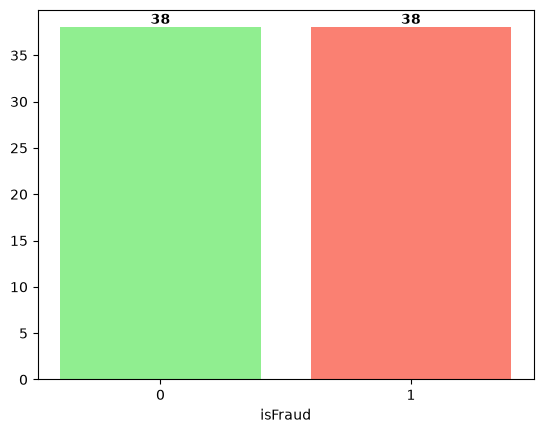

In [26]:
plot_classes(y_res)

In [27]:
def train():
    bst = XGBClassifier(device="cuda")
    start = time.time()
    bst.fit(X_res, y_res)
    end = time.time()
    bst.set_params(device="cpu")
    y_pred = bst.predict(X_test)
    return {"model":bst, "resultat": Resultat("random undersampling",y_test, y_pred, start,end)}
    
runner.run("train")

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


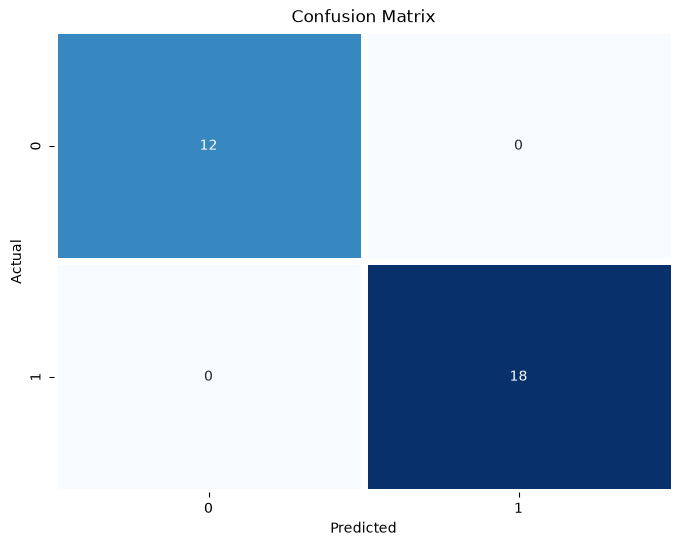

In [29]:
plot_confusion_matrix(y_test,runner.models[2].predict(X_test))

### SMOTE

In [30]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

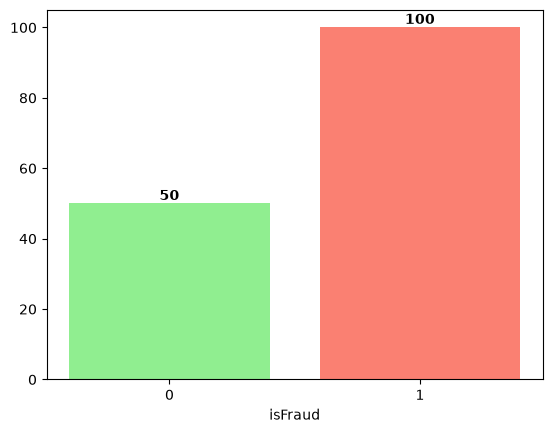

In [31]:
plot_classes(y)

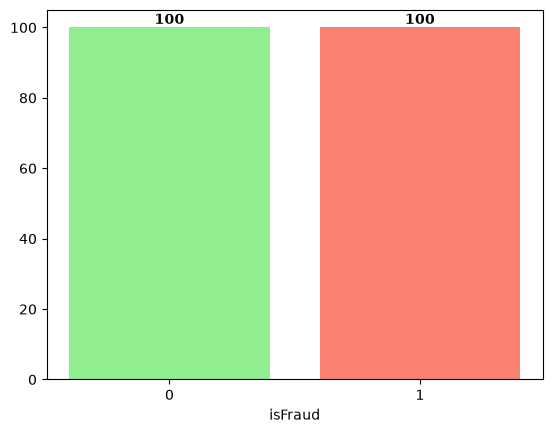

In [32]:
plot_classes(y_res)

In [33]:
def train():
    bst = XGBClassifier(device="cuda")
    start = time.time()
    bst.fit(X_res, y_res)
    end = time.time()
    bst.set_params(device="cpu")
    y_pred = bst.predict(X_test)
    return {"model":bst, "resultat": Resultat("SMOTE",y_test, y_pred, start,end)}

runner.run("train")

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


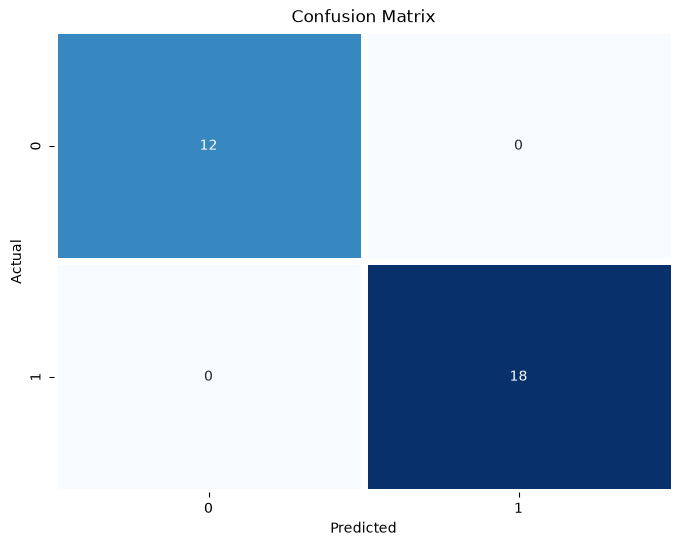

In [34]:
plot_confusion_matrix(y_test,runner.models[3].predict(X_test))

### SMOTE + ENN

In [35]:
smoteenn = SMOTEENN(sampling_strategy='auto', random_state=42)
X_res, y_res = smoteenn.fit_resample(X_train, y_train)


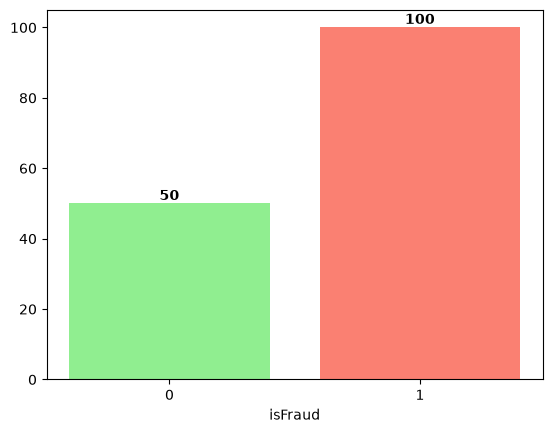

In [36]:
plot_classes(y)

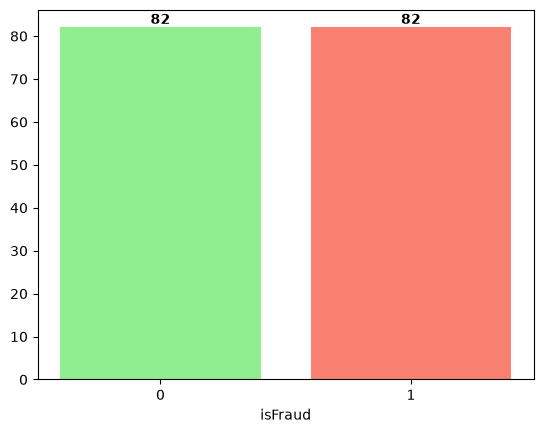

In [37]:
plot_classes(y_res)

In [38]:
def train():
    bst = XGBClassifier(device="cuda")
    start = time.time()
    bst.fit(X_res, y_res)
    end = time.time()
    bst.set_params(device="cpu")
    y_pred = bst.predict(X_test)
    return {"model":bst, "resultat": Resultat("SMOTE+ENN",y_test, y_pred, start,end)}

runner.run("train")

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


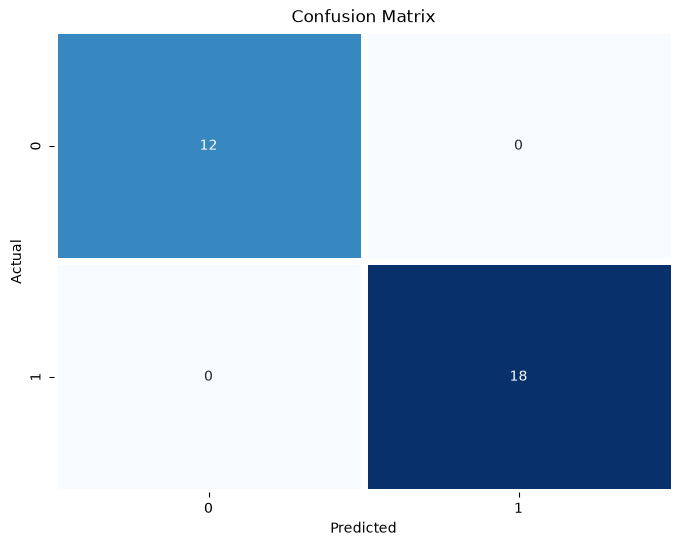

In [39]:
plot_confusion_matrix(y_test,runner.models[4].predict(X_test))

In [40]:
pd.DataFrame(runner.results)

,stratégie,auprc,recall_@_0.5,f1_score,temps (s)
0,baseline,1.0,1.0,1.0,0.0009
1,xgboost pondéré,1.0,1.0,1.0,0.1966
2,random undersampling,1.0,1.0,1.0,0.1803
3,SMOTE,1.0,1.0,1.0,0.2093
4,SMOTE+ENN,1.0,1.0,1.0,0.2212
